In [1]:
# 1. Setup
import os
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import roc_auc_score, classification_report, precision_recall_curve, average_precision_score
import matplotlib.pyplot as plt

DATA_PROCESSED_PATH = "./data/processed/"
RANDOM_STATE = 42

In [2]:
# 2. Load transaction-level data
transactions = pd.read_csv(os.path.join(DATA_PROCESSED_PATH, "SAML-D_clean.csv"))
transactions.head()

,Time,Date,Sender_account,Receiver_account,Amount,Payment_currency,Received_currency,Sender_bank_location,Receiver_bank_location,Payment_type,Is_laundering,Laundering_type,Datetime
0,10:35:19,2022-10-07,8724731955,2769355426,1459.15,UK pounds,UK pounds,UK,UK,Cash Deposit,0,Normal_Cash_Deposits,2022-10-07 10:35:19
1,10:35:31,2022-10-07,5119661534,9734073275,2342.31,UK pounds,UK pounds,UK,UK,Debit card,0,Normal_Small_Fan_Out,2022-10-07 10:35:31
2,10:35:46,2022-10-07,3709430533,9172843471,5274.76,UK pounds,UK pounds,UK,UK,Debit card,0,Normal_Fan_Out,2022-10-07 10:35:46
3,10:36:05,2022-10-07,1203252958,8500212178,2438.30,UK pounds,Mexican Peso,UK,Mexico,Cross-border,0,Normal_Group,2022-10-07 10:36:05
4,10:36:34,2022-10-07,7669236826,6044424887,8560.28,UK pounds,UK pounds,UK,UK,ACH,0,Normal_Fan_Out,2022-10-07 10:36:34


In [3]:
# 3. Feature selection & preprocessing

# Example: select numeric and encoded categorical features
feature_cols = [
    "Amount",
    # add engineered numeric features such as:
    # "hour_of_day", "day_of_week", "currency_mismatch_flag",
    # "sender_risk_score", "receiver_risk_score", etc.
]

X = transactions[feature_cols]
y = transactions["Is_laundering"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [4]:
# 4. Baseline model – Logistic Regression with class_weight
log_reg = LogisticRegression(
    class_weight="balanced",
    max_iter=1000,
    random_state=RANDOM_STATE
)
log_reg.fit(X_train_scaled, y_train)

y_pred_lr = log_reg.predict(X_test_scaled)
y_proba_lr = log_reg.predict_proba(X_test_scaled)[:, 1]

print("Logistic Regression ROC-AUC:", roc_auc_score(y_test, y_proba_lr))
print(classification_report(y_test, y_pred_lr))


Logistic Regression ROC-AUC: 0.5075273224072208
              precision    recall  f1-score   support

           0       1.00      0.80      0.89    189896
           1       0.00      0.24      0.00       202

    accuracy                           0.79    190098
   macro avg       0.50      0.52      0.44    190098
weighted avg       1.00      0.79      0.88    190098



In [5]:
# 5. Tree-based model – Random Forest
rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=None,
    n_jobs=-1,
    class_weight="balanced",
    random_state=RANDOM_STATE
)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)
y_proba_rf = rf.predict_proba(X_test)[:, 1]

print("Random Forest ROC-AUC:", roc_auc_score(y_test, y_proba_rf))
print(classification_report(y_test, y_pred_rf))


Random Forest ROC-AUC: 0.5016347405583546
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    189896
           1       0.00      0.00      0.00       202

    accuracy                           1.00    190098
   macro avg       0.50      0.50      0.50    190098
weighted avg       1.00      1.00      1.00    190098



In [6]:
# 6. Gradient Boosting (as another benchmark)
gb = GradientBoostingClassifier(random_state=RANDOM_STATE)
gb.fit(X_train, y_train)

y_proba_gb = gb.predict_proba(X_test)[:, 1]
print("Gradient Boosting ROC-AUC:", roc_auc_score(y_test, y_proba_gb))


Gradient Boosting ROC-AUC: 0.5803701124367397


Text(0.5, 1.0, 'Random Forest Precision-Recall Curve (AP=0.0060)')

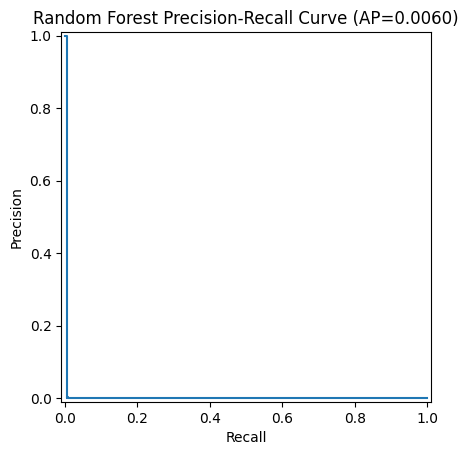

In [7]:
# 7. Precision-Recall curve for best model (e.g. Random Forest)
from sklearn.metrics import PrecisionRecallDisplay

precision, recall, thresholds = precision_recall_curve(y_test, y_proba_rf)
ap = average_precision_score(y_test, y_proba_rf)

disp = PrecisionRecallDisplay(precision=precision, recall=recall)
disp.plot()
disp.ax_.set_title(f"Random Forest Precision-Recall Curve (AP={ap:.4f})")


In [8]:
# 8. Feature importance (for tree-based models)
importances = pd.Series(rf.feature_importances_, index=feature_cols).sort_values(ascending=False)
importances


Amount    1.0
dtype: float64

In [9]:
# 9. (Optional) Customer-level risk scoring
# Aggregate predicted probabilities per customer (sender_id) to build a risk score for credit decisions.

transactions["proba_rf"] = rf.predict_proba(X)[:, 1]
customer_scores = (
    transactions.groupby("Sender_account")["proba_rf"]
    .mean()
    .reset_index()
    .rename(columns={"proba_rf": "risk_score"})
)

customer_scores.head()

,Sender_account,risk_score
0,32095,0.0000
1,61549,0.0000
2,92172,0.0025
3,114277,0.0000
4,153883,0.0000
